In [250]:
# import the necessary modules
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [169]:
# input and output file paths
input_file = "./std_effect.xls"
output_file = "./std_loss_plot.pdf"

# load the dataset
ds = pd.read_excel(input_file)

In [ ]:
ds.head()

In [171]:
# remove the diverged trainings with high perplexity (outliers)
ds = ds[ds['perplexity'] < 10.0]

In [ ]:

# # set the cosmetic plot parameters
# plt.rcParams["font.size"] = 9
# plt.rcParams["axes.labelsize"] = 12
# plt.rcParams["figure.dpi"] = 150

# # set the legend font size
# plt.rcParams["legend.fontsize"] = 8

# # set the color palette to blue, red and green
# sns.set_palette(["darkblue", "red", "green"])

# # set the marker types
# markers = {"tiny": "o", "small": "s", "base": "^"}

# # create a dictionary for dashed line types
# dashes = {"tiny": (2, 2), "small": (3, 2), "base": (4, 2)}

# # plot t-loss and v-loss for tiny, small and base on the same plot
# fig, ax = plt.subplots(figsize=(3.6, 3.6))

# # plot t-losses
# # use solid lines for v-loss and dashed lines for t-loss
# sns.barplot(
#     data=ds[ds['bin_idx'] == 0],
#     x="corrupt",
#     y="t-loss",
#     hue="Name",
#     # style="Name",
#     # markers=markers,
#     # dashes=dashes,
#     errorbar=("ci", 95),
#     ax=ax,
# )

# # create a dictionary of legends.
# legends = {
#     "tiny (t-loss)": ax.get_lines()[0],
#     "small (t-loss)": ax.get_lines()[1],
#     "base (t-loss)": ax.get_lines()[2],
# }

# # plot v-losses
# sns.barplot(
#     data=ds[ds['bin_idx'] == 0],
#     x="corrupt",
#     y="v-loss",
#     hue="Name",
#     # style="Name",
#     # markers=markers,
#     # dashes=False,
#     errorbar=("ci", 95),
#     ax=ax,
# )

# # add three more legends
# legends.update({
#     "tiny (v-loss)": ax.get_lines()[6],
#     "small (v-loss)": ax.get_lines()[7],
#     "base (v-loss)": ax.get_lines()[8],
# })

# # add legends to the plot
# ax.legend(handles=legends.values(), labels=legends.keys())

# # change the y axis label to "loss"
# ax.set_ylabel("loss")

# # change the x axis label to $k$
# ax.set_xlabel("$k$")

# # increase the marker size for triangle
# # for line in ax.get_lines():
# #     if line.get_marker() == "^":
# #         line.set_markersize(6)
# #     else:
# #         line.set_markersize(5)
# #     line.set_markeredgecolor("none")

# # adjust the layout
# fig.tight_layout()

# # set the y axis limit
# # ax.set_ylim(0, 3)

# # save the figure
# fig.savefig(output_file, bbox_inches="tight", dpi=150)

In [ ]:
# create a grid of 3 x 2 subplots for bar plots
# each row corresponds to a model size (tiny, small, base)
# each column corresponds to a loss type (t-loss, v-loss)
# each subplot has corrupt as a hue parameter, bin_idx as x axis and the y axis is the loss value
# remove entries with perplexity > 10.0
fig, axes = plt.subplots(3, 2, figsize=(6, 7), sharey='row')
# set the model sizes and loss types
model_sizes = ['tiny', 'small', 'base']
loss_types = ['t-loss', 'v-loss']
# set the color palette to blue, red and green
sns.set_palette(["darkblue", "red", "green"])
# set the marker types
markers = {"tiny": "o", "small": "s", "base": "^"}
# create a dictionary for dashed line types
dashes = {"tiny": (2, 2), "small": (3, 2), "base": (4, 2)}
# iterate over the model sizes and loss types
for i, model_size in enumerate(model_sizes):
    for j, loss_type in enumerate(loss_types):
        ax = axes[i, j]
        sns.relplot(
            data=ds[ds['Name'] == model_size],
            x="bin_idx",
            y=loss_type,
            hue="corrupt",
            col="Name",
            # errorbar=("ci", 95),
            # capsize=0.1,
            palette=["darkblue", "red", "green"],
            # smaller cap line width for error bars
            # err_kws={'linewidth': 1.5},
            ax=ax,
        )
        # set the x axis label
        ax.set_xlabel("$k$")
        # set the y axis label
        if j == 0:
            ax.set_ylabel("t-loss")
        else:
            ax.set_ylabel("v-loss")
        # set the title
        ax.set_title(f"{model_size} model")
        # adjust the legend
        if i == 0 and j == 0:
            # outside legend before the first subplot
            ax.legend(title="corrupt", bbox_to_anchor=(1.05, 1), loc='upper left')
        # else:
            # ax.get_legend().remove()
# adjust the layout
fig.tight_layout()
# save the figure
# fig.savefig(output_file, bbox_inches="tight", dpi=150)

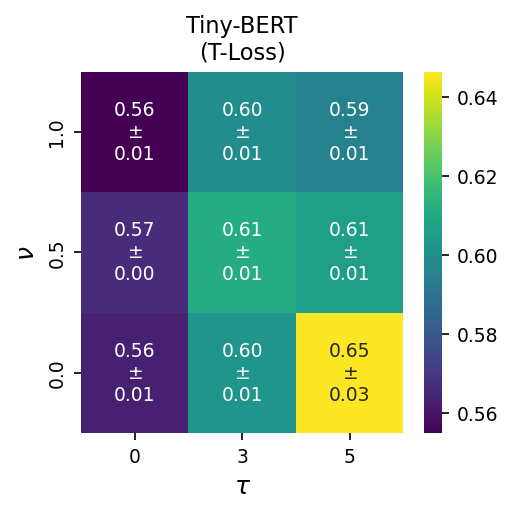

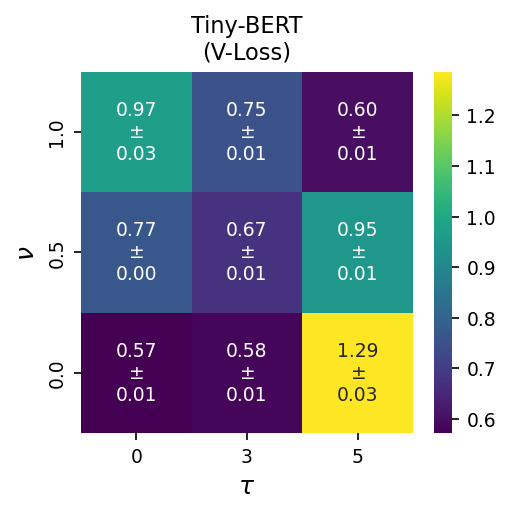

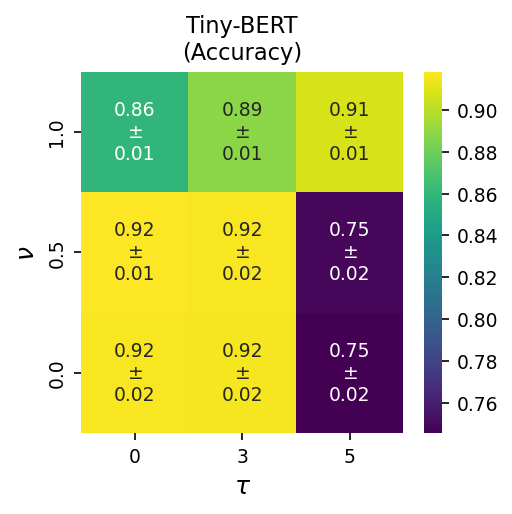

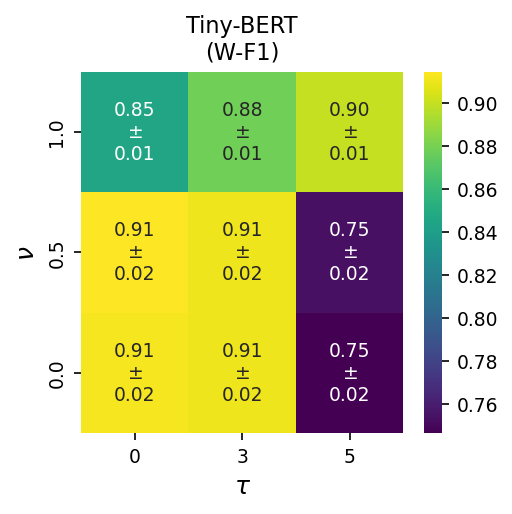

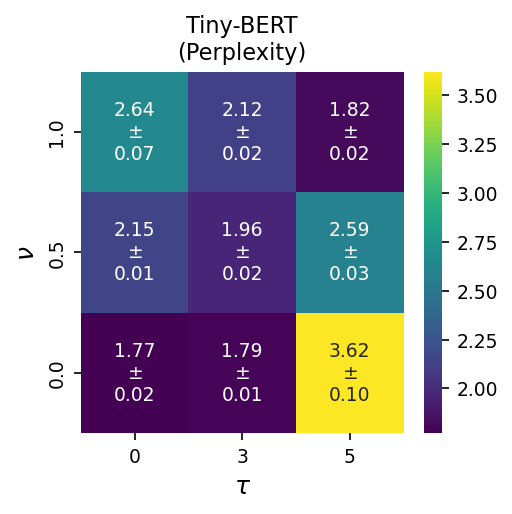

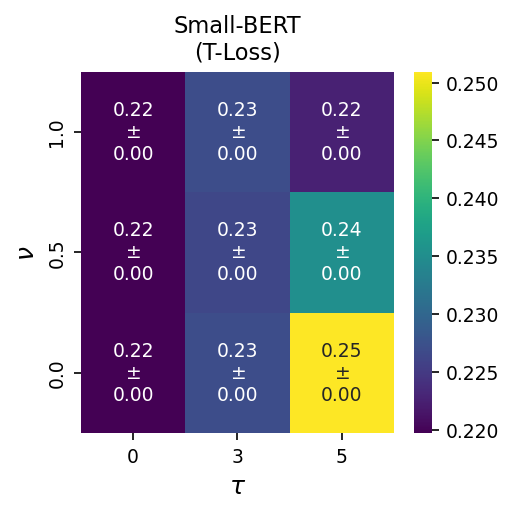

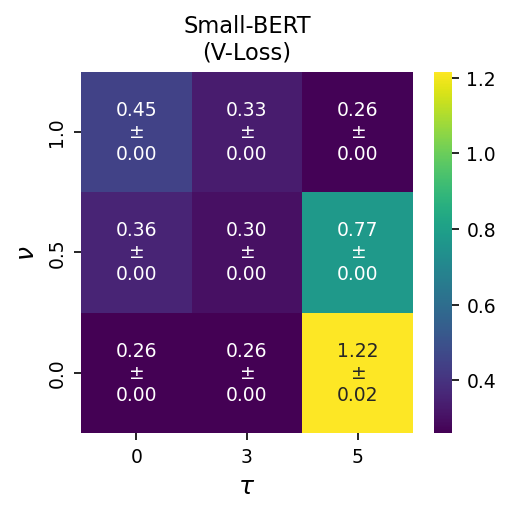

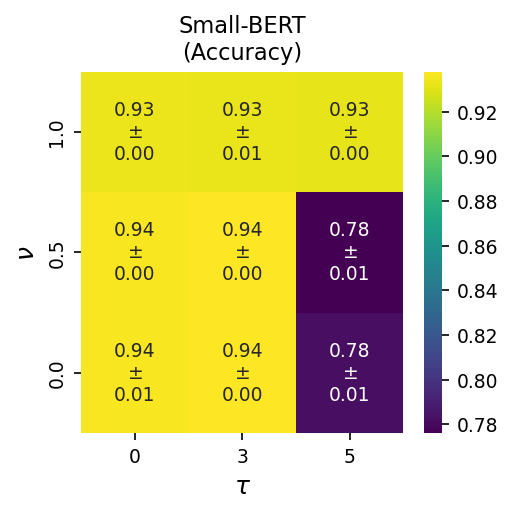

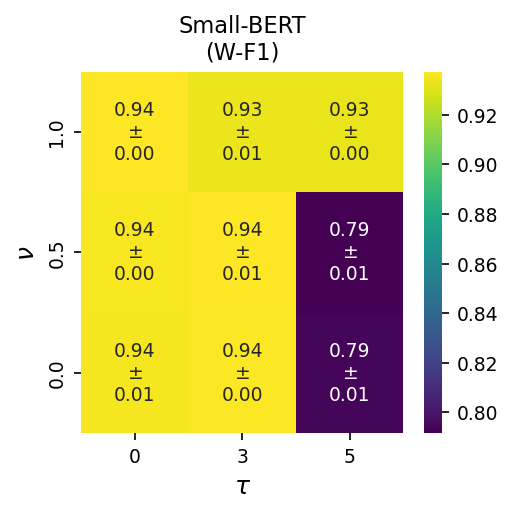

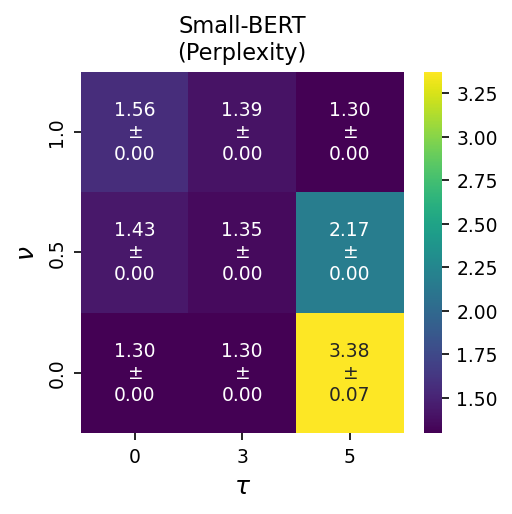

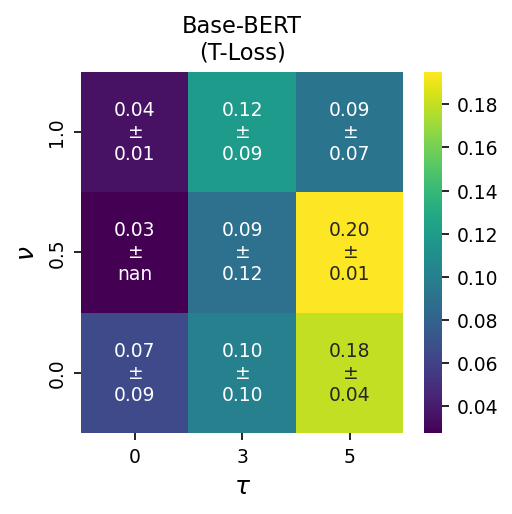

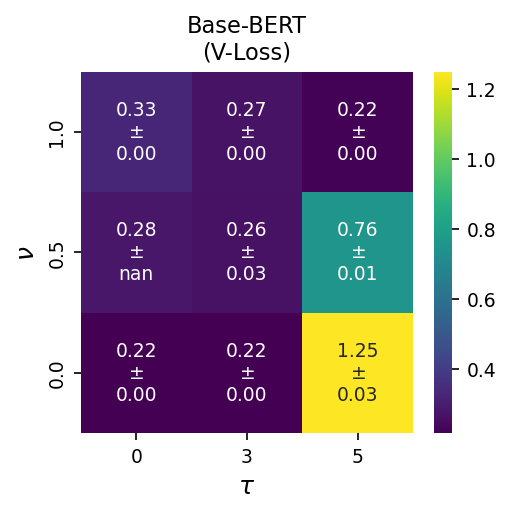

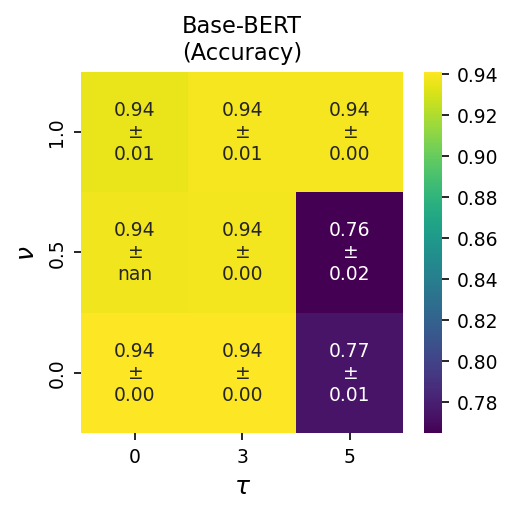

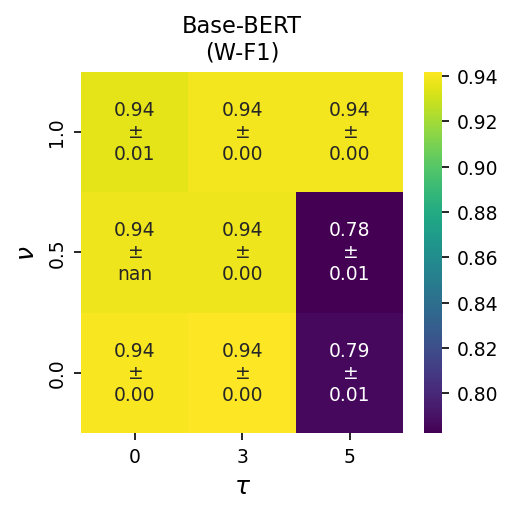

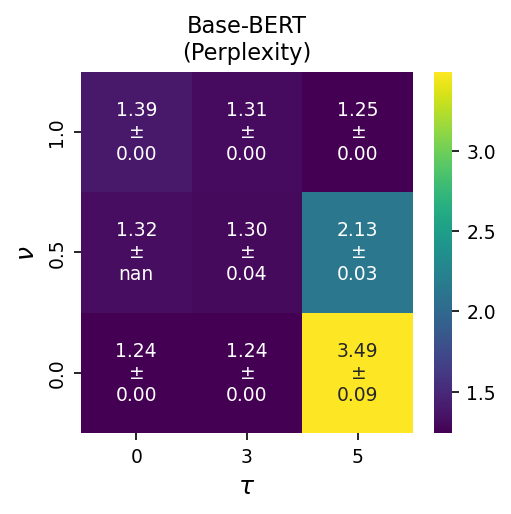

In [260]:
# create heatmaps for t-loss as score and bin_idx and corrupt as x and y axes
# set the figure size to 3.5 x 3.5 inches in dpi=150
model_dict = {"tiny": "Tiny-BERT", "small": "Small-BERT", "base": "Base-BERT"}
metric_dict = {
    "t-loss": "T-Loss",
    "v-loss": "V-Loss",
    "accuracy": "Accuracy",
    "w-f1": "W-F1",
    "perplexity": "Perplexity",
}


def custom_aggfunc(x):
    return f"{x.mean():.2f}\n$\\pm$\n{x.std():.2f}"


for model in model_dict.keys():
    for metric in metric_dict.keys():
        fig, ax = plt.subplots(figsize=(3.5, 3.5), dpi=150)
        annot = ds[ds["Name"] == model].pivot_table(
            index="corrupt", columns="bin_idx", values=metric, aggfunc=custom_aggfunc
        )
        sns.heatmap(
            data=ds[ds["Name"] == model].pivot_table(
                index="corrupt",
                columns="bin_idx",
                values=metric,
                aggfunc="mean",
            ),
            ax=ax,
            cmap="viridis",
            annot=annot,
            fmt='',
        )
        ax.set_title(f"{model_dict[model]}\n({metric_dict[metric]})")
        ax.set_xlabel("$ \\tau $")
        # invert the y axis
        ax.invert_yaxis()
        ax.set_ylabel("$ \\nu $")
        # adjust the layout
        fig.tight_layout()
        # save the figure
        fig.savefig(f"./{model}_{metric}_heatmap.pdf", bbox_inches="tight", dpi=150)

In [ ]:



for metric in ['t-loss', 'v-loss', 'perplexity', "accuracy", "w-f1"]:        
    g = sns.catplot(
        data=ds,
        x="bin_idx",
        y=metric,
        hue="Name",
        errorbar=("ci", 95),
        col="corrupt",
        palette=["darkblue", "red", "green"],
        kind="point",
        # markers=True,
        # markersize=5,
        # capsize=0.1,
        # err_kws={'linewidth': 1.5},
        aspect=1,
        height=4,
    )

    g.set_axis_labels("$k$", metric)
    g.set_titles("{col_name}% corruption")
    g._legend.set_title("corrupt")
# adjust the layout1
g.fig.tight_layout()